# Academia de Física 2026

**Experiência:** Radioatividade em Ação: da Deteção à Compreensão

**Monitores:** Pedro Rodrigues, António Cesário

# Importar Bibliotecas do Python

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Tarefa 1:
### Representação dos Espectros de Energia de Fotões $\gamma$ Associados a Decaimentos Radioativos 

## Tarefa 1.1

In [8]:
#Importar Ficheiro
dados_ruido = pd.read_csv("Ruido.csv", delimiter=";")
print("10 linhas de dados\n")
print(dados_ruido.head(10))

# --------------------------------------
#exemplo de como obter as linhas de dados referentes apenas ao Detetor 1
print("-"*64)
print("10 linhas de dados de referentes ao Detector 0\n")

D0_dados_ruido = dados_ruido[dados_ruido['Detetor'] == 0]
print(D0_dados_ruido.head(10))

# --------------------------------------
#exemplo de como obter as linhas de dados referentes apenas ao Detetor 2
print("-"*64)
print("10 linhas de dados de referentes ao Detector 2\n")

D2_dados_ruido = dados_ruido[dados_ruido['Detetor'] == 2]
print(D2_dados_ruido.head(10))

10 linhas de dados

   Digitalizador  Detetor         Tempo  Energia
0              0        2  7.509004e+09      396
1              0        0  8.677955e+09       25
2              0        2  9.812666e+09       25
3              0        0  1.245303e+10      838
4              0        0  2.197752e+10      150
5              0        0  2.282237e+10      175
6              0        0  2.395434e+10      159
7              0        2  2.576010e+10       76
8              0        0  3.240910e+10      110
9              0        0  3.940182e+10       36
----------------------------------------------------------------
10 linhas de dados de referentes ao Detector 0

    Digitalizador  Detetor         Tempo  Energia
1               0        0  8.677955e+09       25
3               0        0  1.245303e+10      838
4               0        0  2.197752e+10      150
5               0        0  2.282237e+10      175
6               0        0  2.395434e+10      159
8               0        0  

## Tarefa 1.2

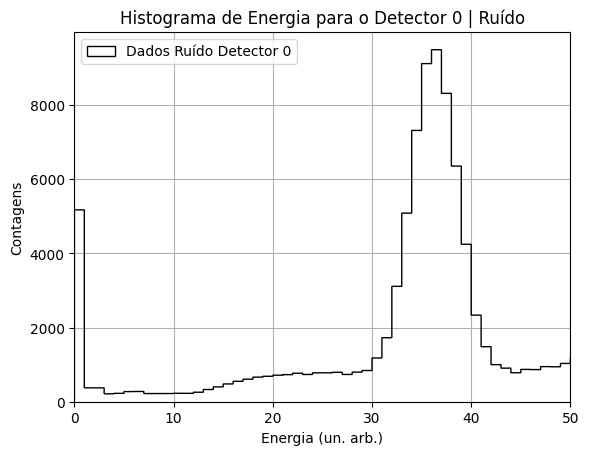

In [9]:
# Filtrar os dados para o Detetor 0 & Seleção de Coluna de Energia
D0_energia_ruido = D0_dados_ruido['Energia']

#histograma y,x,
bins_medidos = np.arange(0, 2000, 1)
contagens, bins, barras = plt.hist(D0_energia_ruido, bins=bins_medidos, color='black', label='Dados Ruído Detector 0', histtype="step")

plt.xlim(0,50)
#plt.yscale("log")

plt.xlabel("Energia (un. arb.)")
plt.ylabel("Contagens")
plt.title("Histograma de Energia para o Detector 0 | Ruído")

plt.legend()
plt.grid(True)
plt.show()

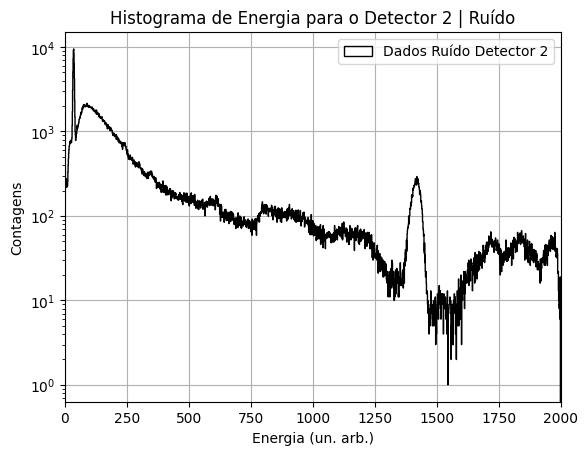

In [10]:
# Filtrar os dados para o Detetor 2 & Seleção de Coluna de Energia
D2_energia_ruido = D2_dados_ruido['Energia']

#histograma y,x,
bins_medidos = np.arange(0, 2000, 1)
contagens, bins, barras = plt.hist(D0_energia_ruido, bins=bins_medidos, color='black', label='Dados Ruído Detector 2', histtype="step")

plt.xlim(0,2000)
plt.yscale("log")

plt.xlabel("Energia (un. arb.)")
plt.ylabel("Contagens")
plt.title("Histograma de Energia para o Detector 2 | Ruído")

plt.legend()
plt.grid(True)
plt.show()

## Tarefa 1.3

In [11]:
# Carregar os dados
dados_22Na = pd.read_csv("Dados_22Na.csv", delimiter=";")

# Filtrar dados por detetor
D0_dados_22Na = dados_22Na[dados_22Na['Detetor'] == 0]
D2_dados_22Na = dados_22Na[dados_22Na['Detetor'] == 2]

# Filtrar dados por energia
D0_energia_22Na = D0_dados_22Na['Energia']
D2_energia_22Na = D2_dados_22Na['Energia']

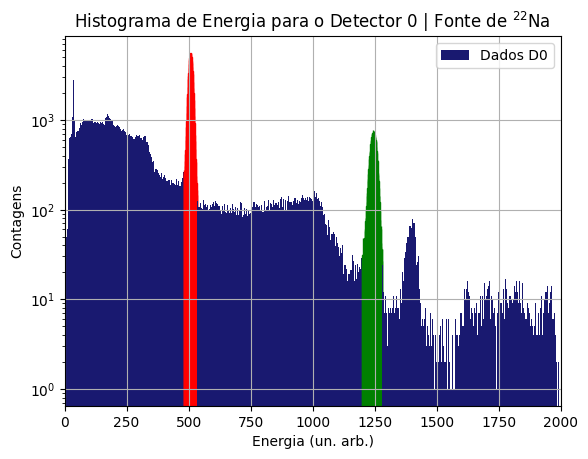

In [12]:
# Representar energias detetor 0
bins_medidos = np.arange(0, 2000, 1)
contagens, bins, barras = plt.hist(D0_energia_22Na, bins=bins_medidos, color='midnightblue', label='Dados D0')#, histtype="step")

# Alterar a cor dos picos de 22Na 511 e 1250 keV
# Alterar cor dos rectângulos
for rectangulo in barras[480:534]:
    rectangulo.set_edgecolor('red')
# Alterar cor dos rectângulos
for rectangulo in barras[1200:1280]:
    rectangulo.set_color('green')

plt.xlim(0,2000)
plt.yscale("log")

plt.xlabel("Energia (un. arb.)")
plt.ylabel("Contagens")
plt.title("Histograma de Energia para o Detector 0 | Fonte de $^{22}$Na")

plt.legend()
plt.grid(True)
plt.show()

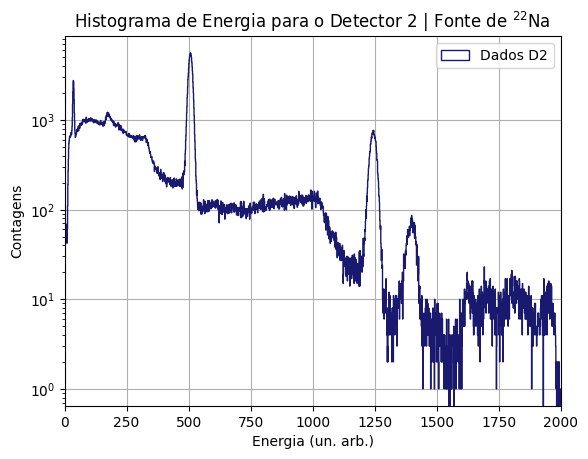

In [13]:
# Representar energias detetor 2
bins_medidos = np.arange(0, 2000, 1)
contagens, bins, barras = plt.hist(D0_energia_22Na, bins=bins_medidos, color='midnightblue', label='Dados D2', histtype="step")

# Alterar a cor dos picos de 22Na 511 e 1250 keV
# Alterar cor dos rectângulos
for rectangulo in barras[480:534]:
    rectangulo.set_edgecolor('red')
# Alterar cor dos rectângulos
for rectangulo in barras[1200:1280]:
    rectangulo.set_ec('green')

plt.xlim(0,2000)
plt.yscale("log")

plt.xlabel("Energia (un. arb.)")
plt.ylabel("Contagens")
plt.title("Histograma de Energia para o Detector 2 | Fonte de $^{22}$Na")

plt.legend()
plt.grid(True)
plt.show()

## Tarefa 1.4

A distribuição de energias medidas por cada detetor pode ser aproximada por uma distribuição Gaussiana (distribuição Normal), que é defnida da seguinte forma:

$$
G(E) = A\exp\left[-\dfrac{\left(E-E_0\right)^2}{2\sigma^2}\right]
$$

onde $E_0$ é o centro da distribuição, $\sigma$ o desvio padrão, $A$ a amplitude, e $G(E)$ é o número de contagens com energia $E$. 

In [14]:
# Definir função Gaussiana
def gaussiana(x, a, x0, sigma):
    return a * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))


 Valor obtido para a LTMA: 18.7

 Valor obtido para a Resolução de energia para o pico 511 keV: 3.7


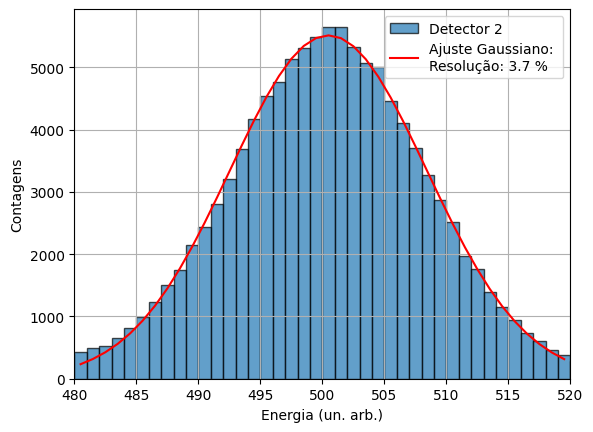

In [15]:
# #######################################
# Pico de energia 512 keV - Detetor 2
# #######################################

# Representar novamente os dados do Detetor 2
bins_medidos = np.arange(0, 2000, 1)
contagens, bins, barras = plt.hist(D2_energia_22Na, bins=bins_medidos, edgecolor='black', alpha=0.7, label="Detector 2")

# Selecionar região de interesse 
intervalo_energia = (480, 520)

#Fazer um array/vetor para o valor de x que seja o centro de cada retangulo/barra do histograma
dados_x = 0.5*(bins[1:]+bins[:-1])

# conjunto de dados experimentais a usar no ajuste
dados_x = dados_x[480:520]
dados_y = contagens[480:520]

# Estimativas de amplitude, posição, e largura da curva gaussiana
p_estimativa = [np.max(dados_y), np.mean(intervalo_energia), 50.0]

# rotina de fazer o ajuste da curva Guassiana aos dados experimentais
popt, _ = curve_fit(gaussiana, dados_x, dados_y, p0=p_estimativa)

# Completado o fit, recolher os resultados
a = popt[0]
x0 = popt[1]
sigma = np.abs(popt[2])

LTMA = 2.355*sigma
R = LTMA/x0 * 100

#print("valores obtidos para o fit: \n Altura (a)"+str(a)+"\n Posição Media (x0): "+str(x0)+"\n o desvio padrão da distribuição (sigma): " str(sigma))
print(f"\n Valor obtido para a LTMA: {LTMA:.1f}")
print(f"\n Valor obtido para a Resolução de energia para o pico 511 keV: {R:.1f}")

y_fit = gaussiana(dados_x, *popt)

plt.plot(dados_x, y_fit, color="red", label=f"Ajuste Gaussiano: \nResolução: {R:.1f} %")

plt.xlabel("Energia (un. arb.)")
plt.xlim(480, 520)
plt.ylabel("Contagens")
plt.legend()
plt.grid(True)
plt.show()


 Valor obtido para a LTMA: 28.8

 Valor obtido para a Resolução de energia para o pico 1250 keV: 2.4


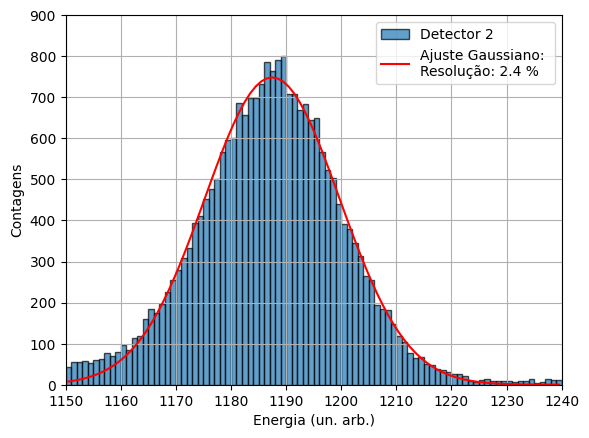

In [16]:
# #######################################
# Pico de energia 1250 keV - Detetor 2
# #######################################

# Representar novamente os dados do Detetor 2
bins_medidos = np.arange(0, 2000, 1)
contagens, bins, barras = plt.hist(D2_energia_22Na, bins=bins_medidos, edgecolor='black', alpha=0.7, label="Detector 2")

# Selecionar região de interesse 
intervalo_energia = (1150, 1240)

#Fazer um array/vetor para o valor de x que seja o centro de cada retangulo/barra do histograma
dados_x = 0.5*(bins[1:]+bins[:-1])

# conjunto de dados experimentais a usar no ajuste
dados_x = dados_x[1150:1240]
dados_y = contagens[1150:1240]

# Estimativas de amplitude, posição, e largura da curva gaussiana
p_estimativa = [np.max(dados_y), np.mean(intervalo_energia), 50.0]

# rotina de fazer o ajuste da curva Guassiana aos dados experimentais
popt, _ = curve_fit(gaussiana, dados_x, dados_y, p0=p_estimativa)

# Completado o fit, recolher os resultados
a = popt[0]
x0 = popt[1]
sigma = np.abs(popt[2])

LTMA = 2.355*sigma
R = LTMA/x0 * 100

#print("valores obtidos para o fit: \n Altura (a)"+str(a)+"\n Posição Media (x0): "+str(x0)+"\n o desvio padrão da distribuição (sigma): " str(sigma))
print(f"\n Valor obtido para a LTMA: {LTMA:.1f}")
print(f"\n Valor obtido para a Resolução de energia para o pico 1250 keV: {R:.1f}")

y_fit = gaussiana(dados_x, *popt)

plt.plot(dados_x, y_fit, color="red", label=f"Ajuste Gaussiano: \nResolução: {R:.1f} %")

plt.xlabel("Energia (un. arb.)")
plt.xlim(1150, 1240)
plt.ylim(0, 900)
plt.ylabel("Contagens")
plt.legend()
plt.grid(True)
plt.show()

## Tarefa 1.5

In [17]:
# Calcular número total de medições que correspondem a fotões com energia 511 keV
Total_511 = np.sum(contagens[480:520])

# Calcular número total de medições que correspondem a fotões com energia 1250 keV
Total_1250 = np.sum(contagens[1150:1240])

print("\nNumero total de fotões registados com energia da ordem de 511 keV")
print(">>>", int(Total_511))

print("\nNumero total de fotões registados com energia da ordem de 1250 keV")
print(">>>", int(Total_1250))

print("\nRácio de #511 : #1250: ")
racio = Total_511 / Total_1250
print(">>>", np.round(racio,2))


Numero total de fotões registados com energia da ordem de 511 keV
>>> 109066

Numero total de fotões registados com energia da ordem de 1250 keV
>>> 23376

Rácio de #511 : #1250: 
>>> 4.67


# Tarefa 2

In [18]:
# Carregar os dados

# Filtrar dados por detetor

# Selecionar as colunas das energias

# Filtrar os dados por energias
## Detetor 0 = energias de START (1250 keV)
## Detetor 2 = energias de STOP (512 keV)

# Calcular coluna de diferenças temporais

# Filter the values between -5000 ps and 50000 ps

In [19]:
# Representar os dados

## Tarefa 2.2

O decaimento exponencial pode ser dado pela equação

$$
N(t) = N_{0}\,e^{-t/\tau}
$$

onde $t$ é o tempo, $N_0$ é número de contagens a $t=0$, $\tau$ a constante de decaimento, e $N(t)$ é o número de contagens esperadas no tempo $t$. 

In [20]:
#Definir a função exponencial

In [21]:
#conjunto de dados experimentais a usar no ajuste

# 2.2  Fazer o ajuste da curva de Decaímento Exponencial aos dados experimentais

## Tarefa 2.3

In [22]:
###################################################################################################
# OBJETIVO:
# Selecionar eventos de coincidência 511 keV - 511 keV entre os detetores D0 e D2
# e calcular o atraso temporal entre deteções para estimar a velocidade da luz.
###################################################################################################

# Ler ficheiro de dados (separador ;)

In [23]:
###################################################################################################
# FILTRO DE ENERGIA
# Selecionar apenas eventos próximos do pico de 511 keV em cada detetor
#
# D0: [506, 545] keV
# D2: [511, 534] keV
###################################################################################################


# Visualizar primeiras linhas


In [24]:
###################################################################################################
# DIFERENÇA TEMPORAL ENTRE EVENTOS CONSECUTIVOS
# Isto permite estimar o tempo entre deteção no D0 e no D2
###################################################################################################

###################################################################################################
# DIFERENÇA ENTRE DETETORES
# Usado para identificar pares consecutivos D0 -> D2
###################################################################################################



In [25]:
###################################################################################################
# SELEÇÃO DE COINCIDÊNCIAS
# Condições:
# - diferença temporal dentro de uma janela razoável (-5000 a 5000 ps)
# - eventos consecutivos de D0 seguido de D2 (Detector_DIFF >= 2)
###################################################################################################



In [26]:
###################################################################################################
# HISTOGRAMA DO ATRASO TEMPORAL
###################################################################################################


In [27]:
###################################################################################################
# CÁLCULO DO TEMPO MÉDIO
###################################################################################################

###################################################################################################
# CÁLCULO DA VELOCIDADE DA LUZ
# Converter ps → s (1 ps = 1e-12 s)
###################################################################################################

###################################################################################################
# NOTA:
# O valor obtido deve ser comparado com o valor nominal da velocidade da luz:
# c = 3.00 × 10^8 m/s
###################################################################################################